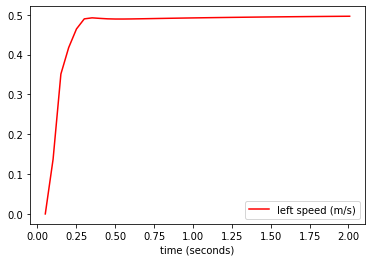

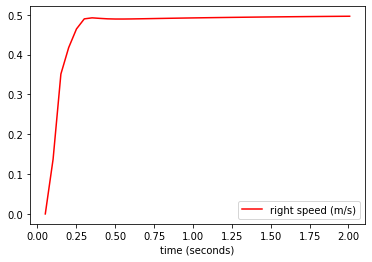

In [12]:
#
# to be tested with godot/single-joint-arm
#

import math
import arslabrobotics as ar

dpleft = ar.data.DataPlotter()
dpleft.set_x("time (seconds)")
dpleft.add_y("speed", "left speed (m/s)")

dpright = ar.data.DataPlotter()
dpright.set_x("time (seconds)")
dpright.add_y("speed", "right speed (m/s)")

dds = ar.dds.DDS()
dds.start()

dds.subscribe(['start','X','Y', 'Theta', 'VL', 'VR'])

speed_ctrl = ar.control.DifferentialDriveSpeedControl(2.0, 1.5, 0.0, 
                                                    10)

speed_ctrl.set_targets(0.5, 0.5)

t = ar.utils.Time()
dds.wait('start')

t.start()
while t.get() < 2:
    
    t.sleep(0.05) # needed to avoid flooding of messages to godot
    dds.wait('tick')
    
    vl = dds.read('VL')
    vr = dds.read('VR')
    
    delta_t = t.elapsed()
    
    (torque_l, torque_r) = speed_ctrl.evaluate(delta_t, vl, vr)

    dpleft.append_x(t.get())
    dpleft.append_y("speed", vl)
    
    dpright.append_x(t.get())
    dpright.append_y("speed", vr)
    
    dds.publish('TL', torque_l, ar.dds.DDS_TYPE_FLOAT)
    dds.publish('TR', torque_r, ar.dds.DDS_TYPE_FLOAT)

# at the end, stop the robot
dds.publish('TL', 0.0, ar.dds.DDS_TYPE_FLOAT)
dds.publish('TR', 0.0, ar.dds.DDS_TYPE_FLOAT)

dpleft.plot()
dpright.plot()

dds.stop()

